In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy
from dcalib import read_dca1000

In [2]:
# fileName="Sitting1Tx1Rx/static_sitting2.bin"
# fileName="Sitting1Tx1Rx/static_sitting2_Raw_0.bin"
fileName="Sitting1Tx1Rx/static_sitting_no_breathing3.bin"
# fileName="Sitting1Tx1Rx/nothing.bin"
# fileName="11_30/11_30_forward_nobreathing_58cm_3_Raw_0.bin"
# fileName="11_30/11_30_nomovement_nobreathing_58cm_3.bin"
dca_out=read_dca1000(fileName,num_adc_samples = 256, num_adc_bits = 16, num_rx=1)

In [3]:
def minmax_normalize(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    
    if max_val - min_val == 0:
        return np.zeros_like(arr)
        
    arr_std = (arr - min_val) / (max_val - min_val)
    
    return arr_std

In [4]:
dca_out.shape

(1, 4194304)

In [5]:
dca_out2=np.zeros((dca_out.shape[0],dca_out.shape[0]//2),dtype=complex)
dca_out2=dca_out[:,0::2]

In [6]:
dca_out=dca_out2

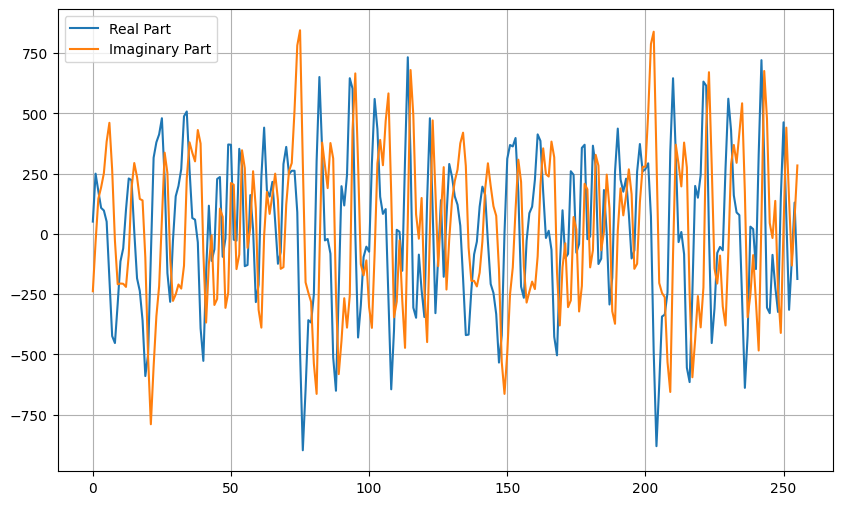

In [7]:
# Time domain
plt.figure(figsize=(10, 6))
chirp=0
num_samples=256
data=dca_out[0][chirp*num_samples:(chirp+1)*num_samples]
# data=dca_out2[0][chirp*num_samples:(chirp+1)*num_samples:1]
real=data.real
complex_data=data.imag
plt.plot(real,'-',label='Real Part')
plt.plot(complex_data,'-',label='Imaginary Part')
plt.grid()
plt.legend()

In [8]:
print(dca_out)
print(dca_out.shape)

[[  51.-238.j  250. -33.j  177.+146.j ... -202. +79.j  -50.+297.j
  -407.+433.j]]
(1, 2097152)


In [9]:
sampling_frequency = 10000 * 1e3 # Hz (example)
S=29.982 * 1e12 #mhz/us
start_freq=77*1e9
ramp_end=60 #us
idle_time=100 #us
periodicity=40 #us
chirp_cycle_time=(idle_time + ramp_end + periodicity) * 1e-6
pulse_repetation_interval = 1/chirp_cycle_time
num_rx=1
num_chirps=1
samples_per_chirp=256
chirps_per_frame=128
range_max=3e8*sampling_frequency/ (2*S)

frames_per_loop=128
chirp_loops=128

dca_out.shape[1]/samples_per_chirp/chirp_loops/frames_per_loop

0.5

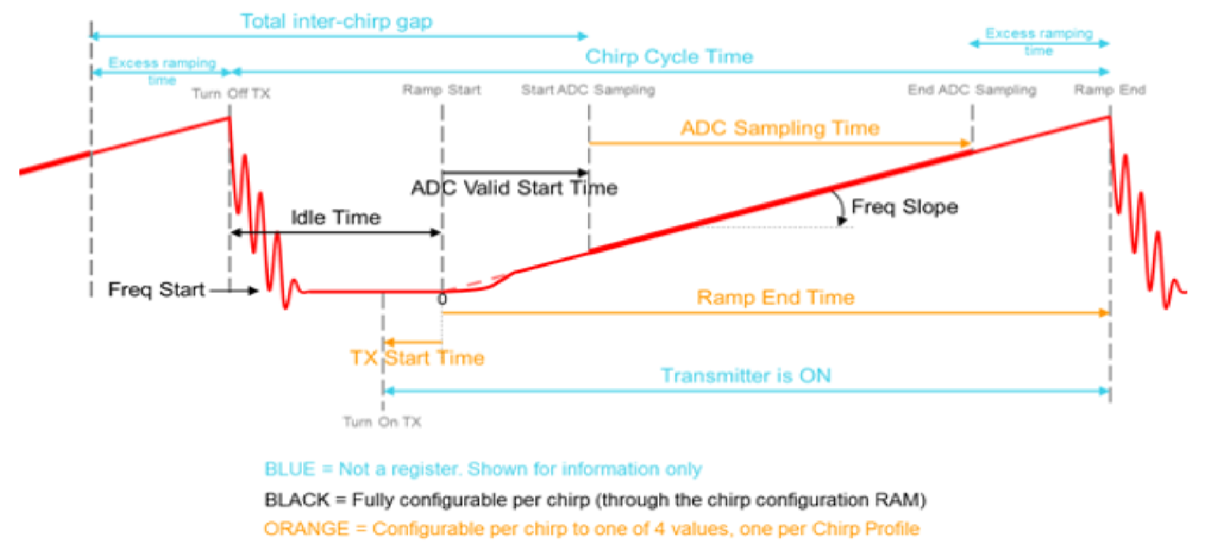

In [10]:
dca_out[0][0]

np.complex128(51-238j)

In [11]:
window = np.hanning(256)
print(window.shape)
print(window[np.newaxis, :].shape)

(256,)
(1, 256)


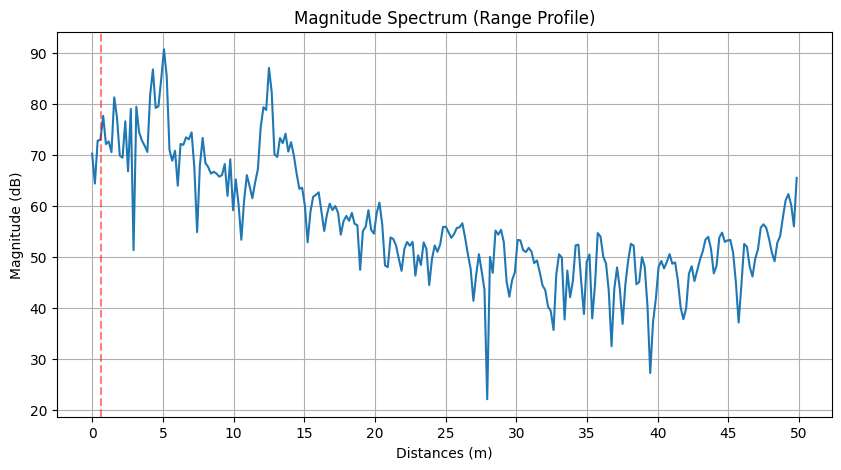

In [12]:
distance_idx=2
def magnitude_dbfs(fft_data, adc_bits=16):
        """
        Convert complex FFT to magnitude in dBFS (decibels relative to full scale)
        
        Args:
            fft_data: Complex FFT output array
            adc_bits: ADC resolution in bits (default 12-bit for typical radar)
        
        Returns:
            magnitude_dbfs: Magnitude in dBFS scale
        """
        # Calculate full scale value based on ADC bits
        full_scale = 2**(adc_bits - 1)  # For signed ADC
        
        # Get magnitude of FFT
        magnitude = np.abs(fft_data)
        
        # Normalize by FFT length (important for proper scaling)
        magnitude_normalized = magnitude / len(fft_data)
        
        # Convert to dBFS: 20*log10(magnitude / full_scale)
        # Add small epsilon to avoid log(0)
        magnitude_dbfs = 20 * np.log10(magnitude_normalized / full_scale + 1e-10)
        
        return magnitude_dbfs

def magnitude_db(fft_data):
        """Convert complex FFT to magnitude in dB"""
        magnitude = np.abs(fft_data)
        magnitude_db = 20 * np.log10(magnitude + 1e-10)  # Add small value to avoid log(0)
        return magnitude_db

def rangeFFT(signal, plot=False):
    global range_max
    num_samples = len(signal)
    window = np.hanning(num_samples)
    signal_windowed = signal * window
    y=np.fft.fft(signal_windowed)
    fft_magnitude = magnitude_db(y,)
    # fft_magnitude = magnitude_dbfs(y,adc_bits=16)

    # frequencies = np.fft.fftshift(np.fft.fftfreq(num_samples, d=1/(sampling_frequency)))
    # distances=np.abs(frequencies)*3e8/2/S
    distances=np.arange(num_samples) * range_max / num_samples
    # print([distances[0],distances[-100]])
    if plot:
        # Plot the magnitude spectrum
        plt.figure(figsize=(10, 5))
        # plt.plot(frequencies[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
        # plt.plot(distances[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
        plt.plot(distances, fft_magnitude) # Plot only positive frequencies
        plt.title('Magnitude Spectrum (Range Profile)')
        # plt.xlabel('Frequency (Hz) / Range Bins')
        plt.xlabel('Distances (m)')
        plt.ylabel('Magnitude (dB)')
        plt.xticks(np.arange(0,range_max,5))
        plt.grid(True)
        plt.axvline(x=0.6, color='r', linestyle='--', alpha=0.5)
        plt.show()
    return y, fft_magnitude, distances

magAtXXcm=[]
sigAtXXcm=[]
distances_all=[]
rangeFFTAcrossChirps=np.zeros([samples_per_chirp,len(dca_out[0])//samples_per_chirp],dtype=np.complex128)
for chirp_no in range(len(dca_out[0])//samples_per_chirp):
    if chirp_no==0:
        fft_signal, fft_magnitude, distances=rangeFFT(dca_out[0][chirp_no*256:(chirp_no+1)*256], plot=True)
    else:
        fft_signal, fft_magnitude, distances=rangeFFT(dca_out[0][chirp_no*256:(chirp_no+1)*256], plot=False)
    rangeFFTAcrossChirps[:,chirp_no]=fft_signal
    sigAtXXcm.append(fft_signal[distance_idx]) 
    magAtXXcm.append(fft_magnitude[distance_idx]) 
    distances_all.append(distances[distance_idx])
sigAt58cm=np.array(sigAtXXcm)
magAt58cm=np.array(magAtXXcm)

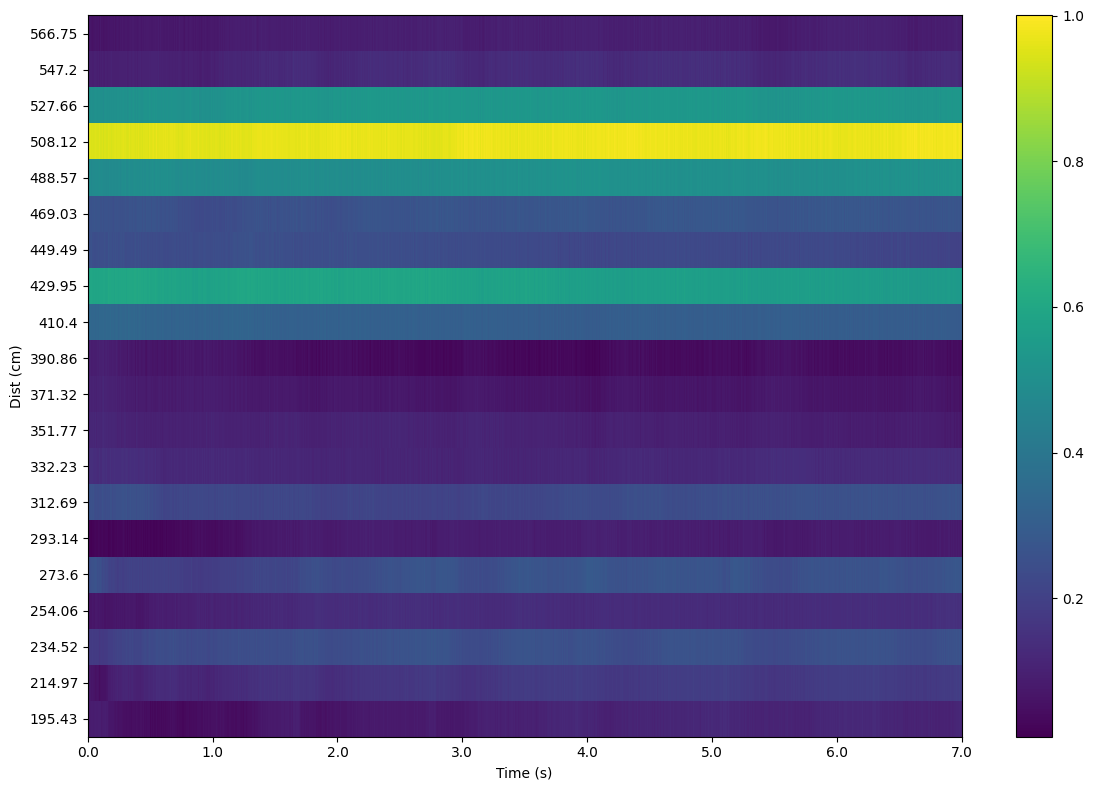

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D array (replace with your own)

distances=np.array(distances)
plt.figure(figsize=(12, 8))
idxes=np.arange(10,30)
x_idxes=np.arange(0,rangeFFTAcrossChirps.shape[1])
rangeFFTAcrossChirps_abs=np.abs(rangeFFTAcrossChirps)
rangeFFTAcrossChirps_norm=(rangeFFTAcrossChirps_abs - np.min(rangeFFTAcrossChirps_abs))/(np.max(rangeFFTAcrossChirps_abs)-np.min(rangeFFTAcrossChirps_abs))
plt.imshow((rangeFFTAcrossChirps_norm[idxes[:, None], x_idxes]), aspect='auto', cmap='viridis', origin='lower',  interpolation='nearest')
# plt.imshow(magnitude_db(rangeFFTAcrossChirps[idxes,:]), aspect='auto', cmap='viridis', origin='lower',interpolation='nearest')

yticks = np.arange(len(rangeFFTAcrossChirps[idxes]))        # positions 0..19
ytick_labels = np.round(distances[idxes]*100,2)                  # your labels
plt.yticks(yticks, ytick_labels)



# --- Create x-ticks for 0–7 seconds ---
total_time = 7  # seconds
num_ticks = 8   # ticks at 0,1,2,...,7 sec

tick_positions = np.linspace(0, rangeFFTAcrossChirps[:,x_idxes].shape[1]-1, num_ticks)
tick_labels = np.linspace(0, total_time, num_ticks)

plt.xticks(tick_positions, tick_labels)
plt.xlabel("Time (s)")
plt.ylabel("Dist (cm)")
plt.colorbar()
plt.tight_layout()
plt.show()


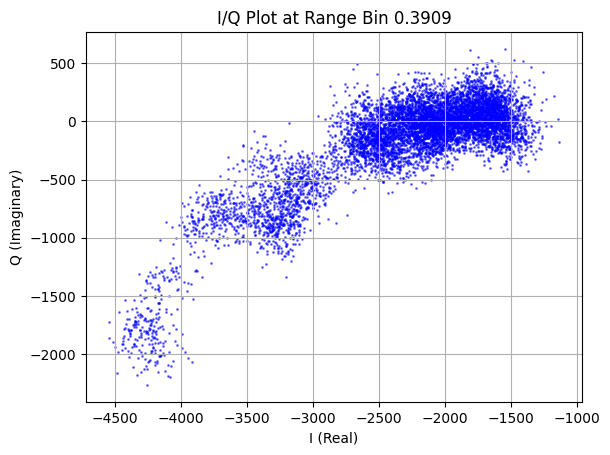

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the complex signal for the specific range bin across all chirps
# This vector represents how the target behaves over 'slow time'
complex_signal = rangeFFTAcrossChirps[distance_idx, :]

# 2. Extract I (Real) and Q (Imaginary) components
I_data = np.real(complex_signal)
Q_data = np.imag(complex_signal)


# 3. Plot
# plt.figure(figsize=(6, 6))  # Square figure is best for IQ plots
plt.scatter(I_data, Q_data, s=1, c='blue', alpha=0.5) # s=1 for small points like your image

# Optional: Make it look exactly like your reference
# plt.xlim([-5e4, 5e4]) # Adjust scale to match your data
# plt.ylim([-5e4, 5e4])

plt.title(f'I/Q Plot at Range Bin {np.round(distances[distance_idx],4)}')
plt.xlabel('I (Real)')
plt.ylabel('Q (Imaginary)')
plt.grid(True)
# plt.axis('equal') # Important: Keeps circles looking like circles, not ovals
plt.show()

# Doppler FFT
## The following code assumes that all chirps belong to just one frame. 

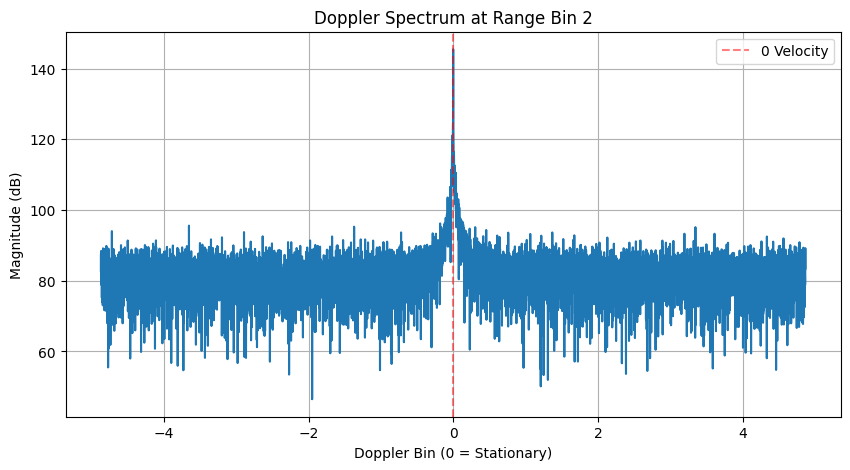

In [15]:

dop_all_fft=np.fft.fft(rangeFFTAcrossChirps,axis=1) # axis = 1 to perform fft across 640 rows.
dop_fft=dop_all_fft[distance_idx,:]


# 1. Shift the zero-frequency component to the center of the spectrum
dop_fft_shifted = np.fft.fftshift(dop_fft)

# 2. Get magnitude in dB
dop_mag_db = 20 * np.log10(np.abs(dop_fft_shifted) + 1e-10)

# 3. Create an axis for the plot (Indices centered around 0)
num_chirps = dop_fft.shape[0]
velocity_axis = np.arange(-num_chirps/2, num_chirps/2)
velocity_axis = velocity_axis * 3e8/(start_freq * num_chirps * chirp_cycle_time * 2)
# 4. Plot
plt.figure(figsize=(10, 5))
plt.plot(velocity_axis, dop_mag_db)
plt.title(f'Doppler Spectrum at Range Bin {distance_idx}')
plt.xlabel('Doppler Bin (0 = Stationary)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='0 Velocity')
plt.legend()
plt.show()

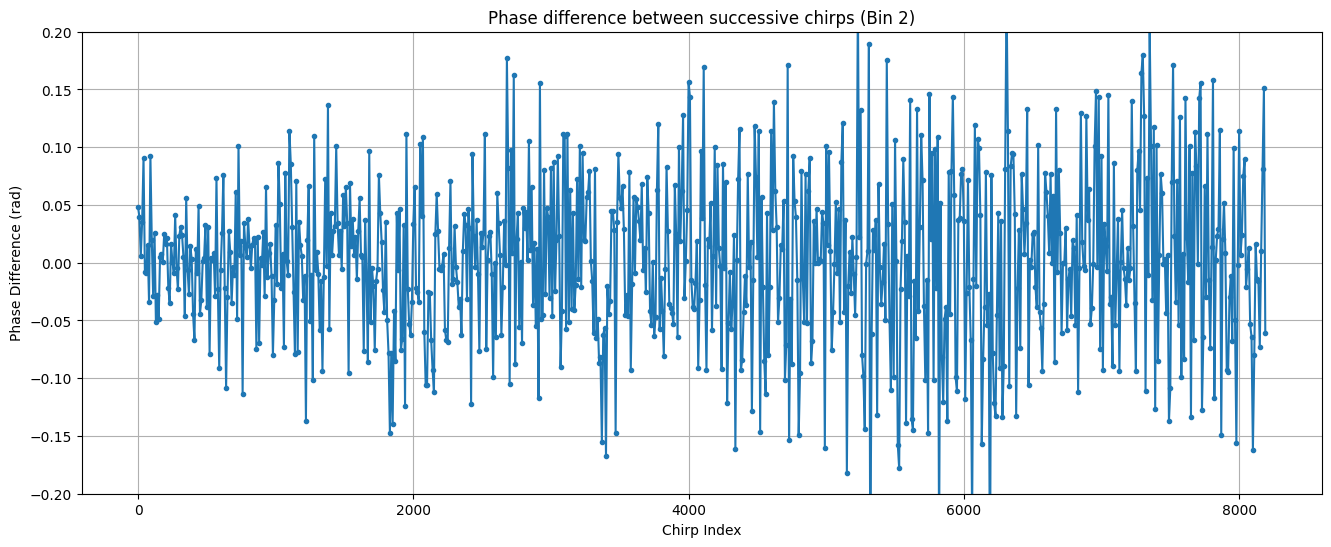

In [16]:
# 1. Get the Time-Domain signal (Slow Time) for the specific range bin
# Do NOT use the output of the FFT; use the input to the FFT.
slow_time_signal = rangeFFTAcrossChirps[distance_idx, :] 

# 2. Calculate phase difference between successive CHIRPS
# (Current Chirp * Conjugate of Previous Chirp)
phi_diff = np.angle(slow_time_signal[1:] * np.conj(slow_time_signal[:-1])) # radians

# Optional: Convert phase difference -> velocity (m/s)
# velocity = (phi_diff * wavelength) / (4 * np.pi * chirp_duration)

# Plotting
plt.figure(figsize=(16, 6))
skip = 10 # Plot every point to see the full trend

plt.plot(
    np.arange(len(phi_diff))[::skip],
    phi_diff[::skip],
    '.-'
)
plt.ylim([-0.2, 0.2])

plt.xlabel("Chirp Index")
plt.ylabel("Phase Difference (rad)")
plt.title(f"Phase difference between successive chirps (Bin {distance_idx})")
plt.grid(True)
plt.show()

# If you need this for ALL range bins:
phi_diff_all = np.angle(
    rangeFFTAcrossChirps[:, 1:] * np.conj(rangeFFTAcrossChirps[:, :-1])
)

Text(0, 0.5, 'magnitude (dB)')

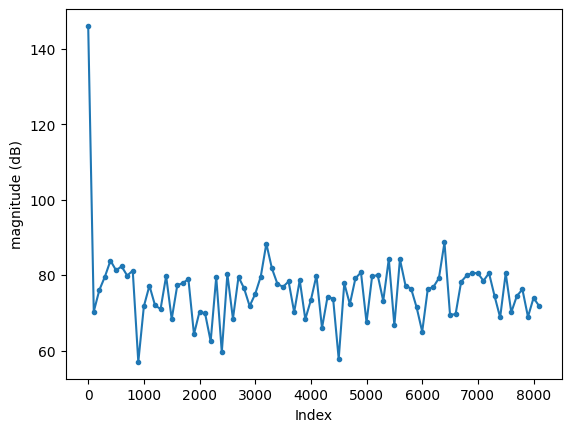

In [17]:
# def dopFFT(signal, plot=False):
#     global range_max
#     num_samples = len(signal)
#     window = np.hanning(num_samples)
#     signal_windowed = signal * window
#     y=np.fft.fft(signal_windowed)
#     fft_magnitude = magnitude_db(y,)
#     # fft_magnitude = magnitude_dbfs(y,adc_bits=16)

#     # frequencies = np.fft.fftshift(np.fft.fftfreq(num_samples, d=1/(sampling_frequency)))
#     # distances=np.abs(frequencies)*3e8/2/S
#     distances=np.arange(num_samples) * range_max / num_samples
#     # print([distances[0],distances[-100]])
#     if plot:
#         # Plot the magnitude spectrum
#         plt.figure(figsize=(10, 5))
#         # plt.plot(frequencies[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
#         # plt.plot(distances[:num_samples//2], fft_magnitude[:num_samples//2]) # Plot only positive frequencies
#         plt.plot(distances, fft_magnitude) # Plot only positive frequencies
#         plt.title('Magnitude Spectrum (Range Profile)')
#         # plt.xlabel('Frequency (Hz) / Range Bins')
#         plt.xlabel('Distances (m)')
#         plt.ylabel('Magnitude [dBFS]')
#         plt.xticks(np.arange(0,range_max,5))
#         plt.grid(True)
#         plt.axvline(x=0.6, color='r', linestyle='--', alpha=0.5)
#         plt.show()
#     return y, fft_magnitude, distances
window = np.hanning(num_chirps)
dop_all_fft=np.fft.fft(rangeFFTAcrossChirps * window,axis=1)
dop_fft=dop_all_fft[3,:]
skip=100
plt.plot(np.arange(len(dop_fft)/skip)*skip,magnitude_db(dop_fft)[::skip],'.-')
# plt.plot(np.arange(len(dop_fft)/skip)*skip,dop_fft[::skip],'.-')
plt.xlabel("Index")
plt.ylabel("magnitude (dB)")

Number of samples: 2048
Number of chirps: 8
Mean phase acceleration: 31684965439.38 rad/s²
Estimated target acceleration: 19647346.25 m/s²


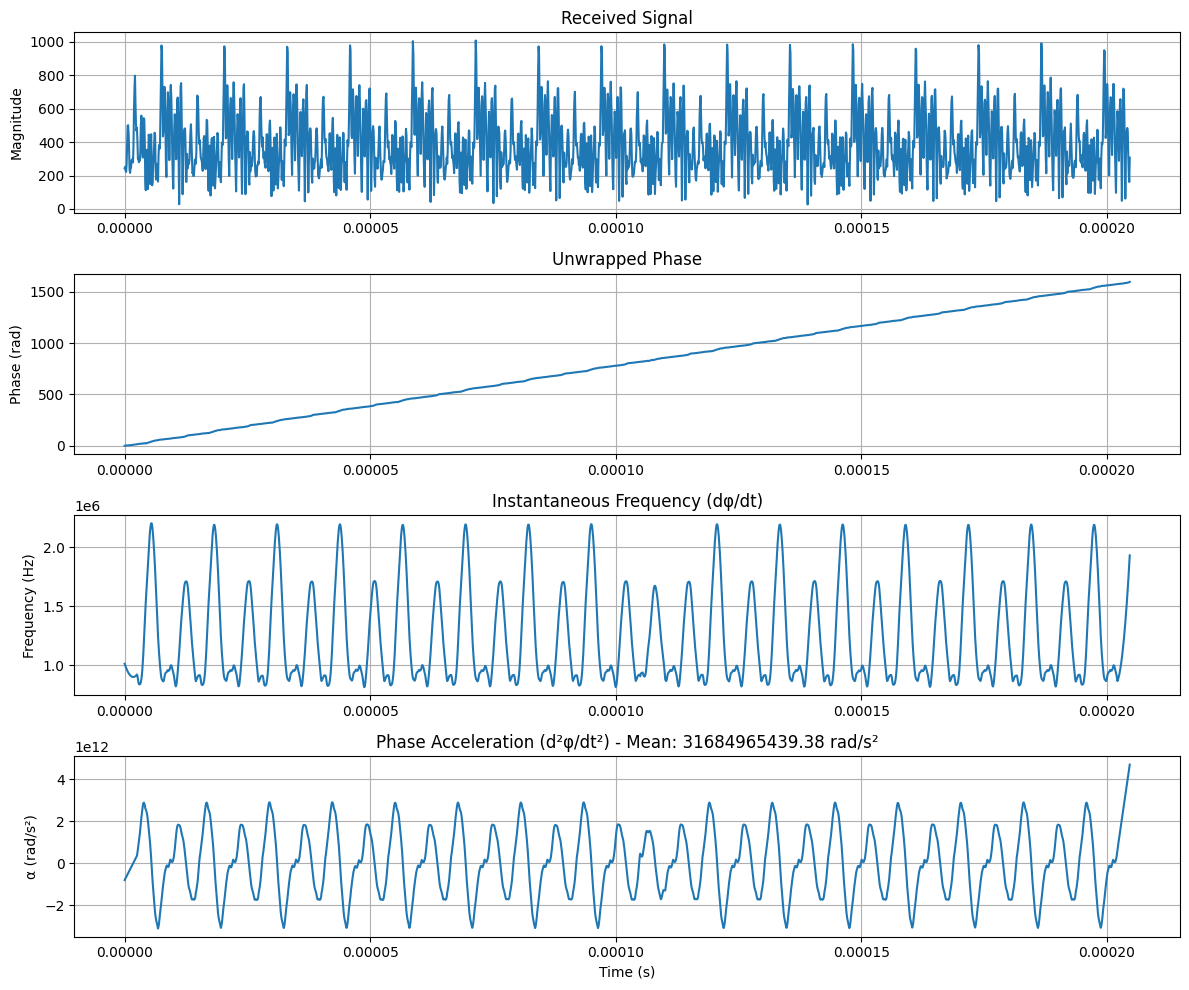

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, savgol_filter
from scipy.fft import fft, fftfreq

class mmWavePhaseAnalyzer:
    """Analyze phase acceleration from mmWave radar data"""
    
    def __init__(self, data, fs, fc, samples_per_chirp=256):
        """
        Initialize analyzer
        
        Parameters:
        - data: 1D array - Complex IQ data or real signal from RX antenna
        - fs: Sampling frequency (Hz)
        - fc: Carrier frequency (Hz)
        - samples_per_chirp: Number of samples per chirp (default: 256)
        """
        self.fs = fs
        self.fc = fc
        self.dt = 1/fs
        self.samples_per_chirp = samples_per_chirp
        
        # Convert to complex if real-valued
        if np.isrealobj(data):
            self.signal = hilbert(data)
        else:
            self.signal = data
            
        self.time = np.arange(len(self.signal)) * self.dt
        self.num_chirps = len(self.signal) // samples_per_chirp
        
    def extract_phase(self, unwrap=True):
        """Extract instantaneous phase from signal"""
        phase = np.angle(self.signal)
        
        if unwrap:
            phase = np.unwrap(phase)
            
        return phase
    
    def calculate_inst_frequency(self, phase=None, smooth=True, window=51, poly=3):
        """
        Calculate instantaneous frequency (first derivative of phase)
        
        Parameters:
        - phase: Unwrapped phase (if None, will be computed)
        - smooth: Apply smoothing filter
        - window: Savitzky-Golay filter window size (must be odd)
        - poly: Polynomial order for smoothing
        """
        if phase is None:
            phase = self.extract_phase(unwrap=True)
        
        # First derivative
        if smooth and len(phase) > window:
            omega = savgol_filter(phase, window, poly, deriv=1, delta=self.dt)
        else:
            omega = np.gradient(phase, self.dt)
        
        # Convert to Hz
        freq = omega / (2 * np.pi)
        
        return omega, freq
    
    def calculate_phase_acceleration(self, phase=None, smooth=True, window=51, poly=3):
        """
        Calculate phase acceleration (second derivative of phase)
        
        Parameters:
        - phase: Unwrapped phase (if None, will be computed)
        - smooth: Apply smoothing filter
        - window: Savitzky-Golay filter window size (must be odd)
        - poly: Polynomial order for smoothing
        """
        if phase is None:
            phase = self.extract_phase(unwrap=True)
        
        # Second derivative
        if smooth and len(phase) > window:
            alpha = savgol_filter(phase, window, poly, deriv=2, delta=self.dt)
        else:
            alpha = np.gradient(np.gradient(phase, self.dt), self.dt)
        
        return alpha
    
    def estimate_target_acceleration(self, alpha):
        """
        Estimate physical acceleration from phase acceleration
        Assumes Doppler scenario: alpha = 2*pi*fc * (a/c)
        
        Returns acceleration in m/s²
        """
        c = 3e8  # Speed of light
        a = (alpha * c) / (2 * np.pi * self.fc)
        return a
    
    def analyze(self, smooth=True, window=51, poly=3):
        """
        Complete analysis pipeline
        
        Returns dictionary with all results
        """
        # Extract phase
        phase = self.extract_phase(unwrap=True)
        
        # Calculate derivatives
        omega, freq = self.calculate_inst_frequency(phase, smooth, window, poly)
        alpha = self.calculate_phase_acceleration(phase, smooth, window, poly)
        
        # Estimate physical parameters
        target_accel = self.estimate_target_acceleration(alpha)
        
        results = {
            'time': self.time,
            'signal': self.signal,
            'phase': phase,
            'angular_freq': omega,
            'frequency': freq,
            'phase_accel': alpha,
            'target_accel': target_accel,
            'mean_phase_accel': np.mean(alpha),
            'std_phase_accel': np.std(alpha),
            'mean_target_accel': np.mean(target_accel),
            'std_target_accel': np.std(target_accel)
        }
        
        return results
    
    def plot_analysis(self, results):
        """Plot comprehensive analysis"""
        fig, axes = plt.subplots(4, 1, figsize=(12, 10))
        
        # Signal magnitude
        axes[0].plot(results['time'], np.abs(results['signal']))
        axes[0].set_ylabel('Magnitude')
        axes[0].set_title('Received Signal')
        axes[0].grid(True)
        
        # Unwrapped phase
        axes[1].plot(results['time'], results['phase'])
        axes[1].set_ylabel('Phase (rad)')
        axes[1].set_title('Unwrapped Phase')
        axes[1].grid(True)
        
        # Instantaneous frequency
        axes[2].plot(results['time'], results['frequency'])
        axes[2].set_ylabel('Frequency (Hz)')
        axes[2].set_title('Instantaneous Frequency (dφ/dt)')
        axes[2].grid(True)
        
        # Phase acceleration
        axes[3].plot(results['time'], results['phase_accel'], label='Phase Accel')
        axes[3].set_ylabel('α (rad/s²)')
        axes[3].set_xlabel('Time (s)')
        axes[3].set_title(f'Phase Acceleration (d²φ/dt²) - Mean: {results["mean_phase_accel"]:.2f} rad/s²')
        axes[3].grid(True)
        
        plt.tight_layout()
        return fig


# Initialize analyzer with YOUR data
analyzer = mmWavePhaseAnalyzer(
    data=dca_out[0][:2048],             # Your 1D array
    fs=sampling_frequency,       # Sampling frequency
    fc=77e9,                       # Carrier frequency  
    samples_per_chirp=256        # Already set to 256
)

# Run analysis
results = analyzer.analyze(
    smooth=True,     # Recommended for noisy data
    window=51,       # Smoothing window (adjust based on noise)
    poly=3          # Polynomial order
)

# Print results
print(f"Number of samples: {len(dca_out[0][:2048])}")
print(f"Number of chirps: {analyzer.num_chirps}")
print(f"Mean phase acceleration: {results['mean_phase_accel']:.2f} rad/s²")
print(f"Estimated target acceleration: {results['mean_target_accel']:.2f} m/s²")

# Visualize
fig = analyzer.plot_analysis(results)
plt.show()

# Access specific results
phase = results['phase']              # Unwrapped phase
freq = results['frequency']           # Instantaneous frequency
phase_accel = results['phase_accel']  # Phase acceleration (rad/s²)
target_accel = results['target_accel'] # Target acceleration (m/s²)


# print(example_code)